# Multilayer Perceptron

Binary classification on California housing: predict whether median house value is above the median.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

data_df = pd.read_csv("housing.csv")
data_df['total_bedrooms'] = data_df['total_bedrooms'].fillna(data_df['total_bedrooms'].median())
data_df = pd.get_dummies(data_df, columns=['ocean_proximity'], dtype=float)

threshold = data_df['median_house_value'].median()
y = (data_df['median_house_value'] > threshold).astype(int).to_numpy()
X = data_df.drop(columns=['median_house_value']).to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=True, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(np.bincount(y_train), np.bincount(y_test))

(13828, 13) (6812, 13)
[6916 6912] [3407 3405]


## Baseline MLP

sklearn `MLPClassifier` with one hidden layer as the starting point.

Accuracy: 0.8842
[[3101  306]
 [ 483 2922]]
              precision    recall  f1-score   support

       Below       0.87      0.91      0.89      3407
       Above       0.91      0.86      0.88      3405

    accuracy                           0.88      6812
   macro avg       0.89      0.88      0.88      6812
weighted avg       0.89      0.88      0.88      6812



/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


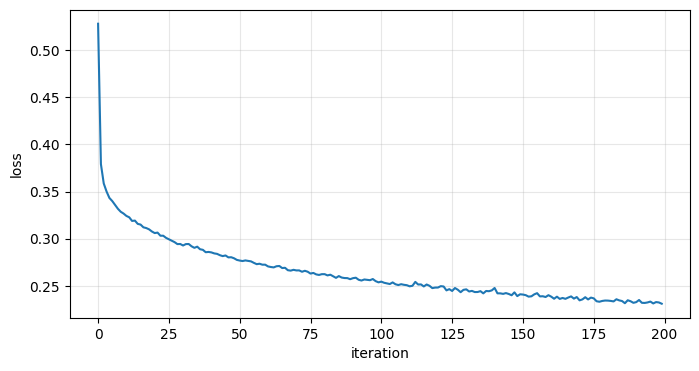

In [2]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                    solver='adam', max_iter=200, random_state=42)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Below', 'Above']))

plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.grid(alpha=0.3)
plt.show()

## Architecture comparison

A few configurations — single hidden layer of varying width, then a couple of two-layer setups, then something deeper. Looking at how capacity changes test accuracy.

/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


(16,)                train=0.8668 test=0.8691


/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


(64,)                train=0.8787 test=0.8743


/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


...

(32, 16)             train=0.8828 test=0.8815


/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


(64, 32)             train=0.9023 test=0.8842


(128, 64, 32)        train=0.9295 test=0.8801


/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


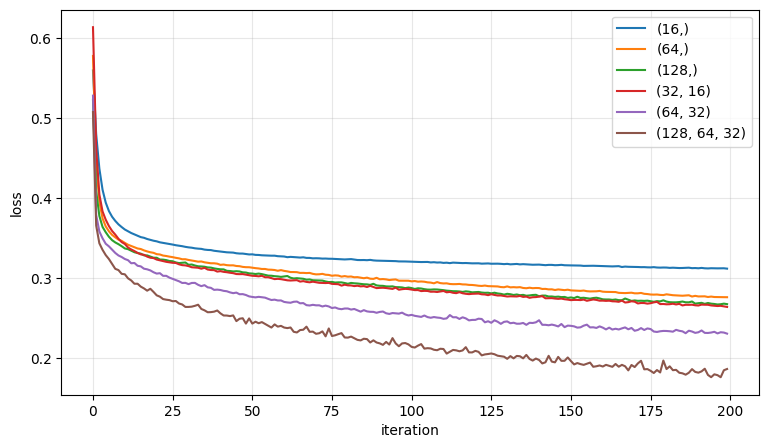

In [3]:
archs = [(16,), (64,), (128,), (32, 16), (64, 32), (128, 64, 32)]
results = []

for arch in archs:
    m = MLPClassifier(hidden_layer_sizes=arch, activation='relu',
                      solver='adam', max_iter=200, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    results.append((str(arch), tr, te, m.loss_curve_))
    print(f"{str(arch):<20} train={tr:.4f} test={te:.4f}")

plt.figure(figsize=(9, 5))
for label, _, _, curve in results:
    plt.plot(curve, label=label)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Activation function comparison

Four activations at fixed architecture:

- **ReLU**: $\phi(z) = \max(0, z)$ — fast, doesn't saturate for $z > 0$
- **tanh**: zero-centered, saturates at ±1
- **logistic**: $\sigma(z) = 1/(1 + e^{-z})$, saturates at 0 and 1
- **identity**: $\phi(z) = z$ — collapses the network to a linear model

ReLU is the modern default; identity is here mainly to confirm the network *needs* nonlinearity to beat logistic regression.

identity   train=0.8352 test=0.8440


/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


logistic   train=0.8615 test=0.8677


/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


tanh       train=0.9003 test=0.8871


relu       train=0.9023 test=0.8842


/Users/aaravgupta/Documents/cmor_project/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


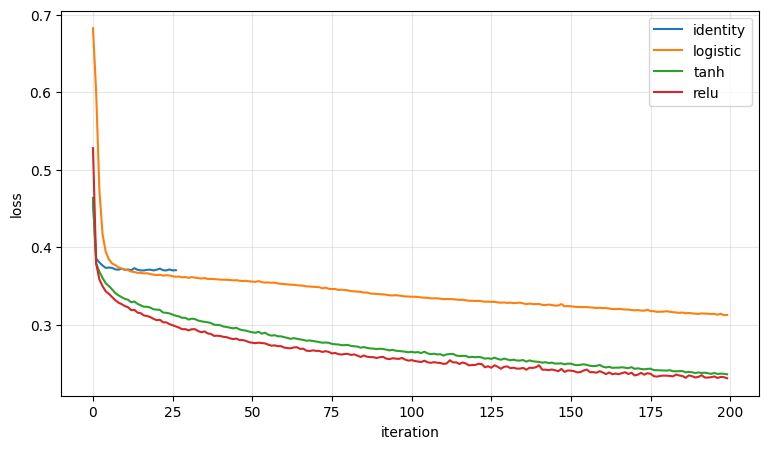

In [4]:
activations = ['identity', 'logistic', 'tanh', 'relu']
act_results = []

for act in activations:
    m = MLPClassifier(hidden_layer_sizes=(64, 32), activation=act,
                      solver='adam', max_iter=200, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    act_results.append((act, tr, te, m.loss_curve_))
    print(f"{act:<10} train={tr:.4f} test={te:.4f}")

plt.figure(figsize=(9, 5))
for label, _, _, curve in act_results:
    plt.plot(curve, label=label)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## From-scratch MLP (one hidden layer)

Manual forward + backprop in numpy. Forward pass with ReLU hidden + sigmoid output:

$$a = \text{ReLU}(W^{(1)} x + b^{(1)}), \quad \hat y = \sigma(W^{(2)} a + b^{(2)})$$

Backward pass propagates the gradient through both layers via chain rule. Same structure as `src/rice_ml/supervised_ml/mlp.py`.

Scratch train acc: 0.8551
Scratch test acc:  0.8607


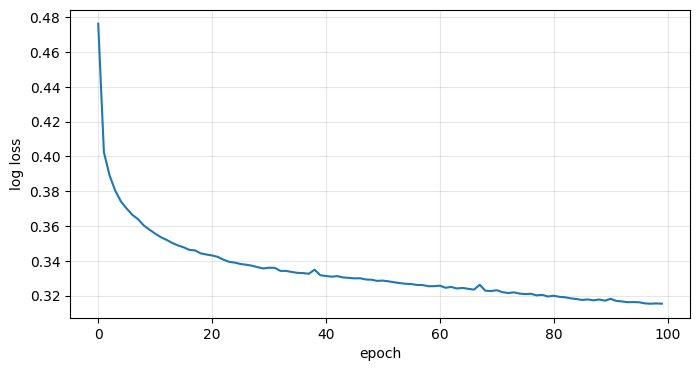

In [5]:
from rice_ml.supervised_ml import MLP as MLPScratch

scratch = MLPScratch(hidden=64, lr=0.05, epochs=100, batch=128).fit(X_train, y_train)
print(f"Scratch train acc: {accuracy_score(y_train, scratch.predict(X_train)):.4f}")
print(f"Scratch test acc:  {accuracy_score(y_test, scratch.predict(X_test)):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(scratch.loss_)
plt.xlabel('epoch')
plt.ylabel('log loss')
plt.grid(alpha=0.3)
plt.show()

## ROC curve

ROC + AUC on the best sklearn model's predicted probabilities.

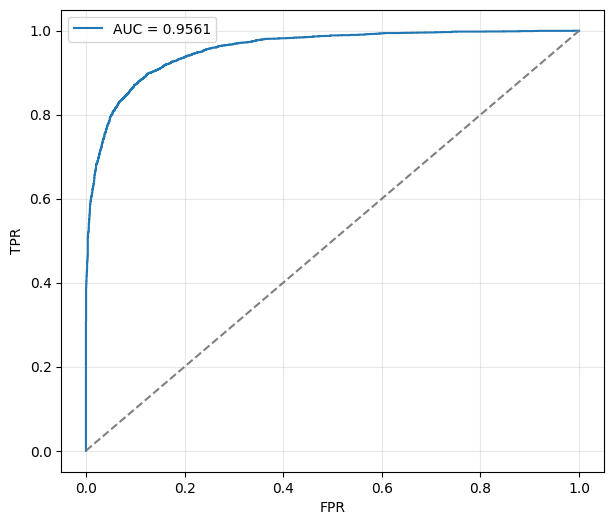

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()